In [1]:
! pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


## Load Kaggle Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pkdarabi/bone-break-classification-image-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bone-break-classification-image-dataset' dataset.
Path to dataset files: /kaggle/input/bone-break-classification-image-dataset


In [3]:
import shutil
from pathlib import Path

dest = Path("./data/bone-break")  # your project path
dest.mkdir(parents=True, exist_ok=True)
for item in Path(path).iterdir():
    tgt = dest / item.name
    if item.is_dir():
        shutil.copytree(item, tgt, dirs_exist_ok=True)
    else:
        shutil.copy2(item, tgt)
print("Copied to:", dest)

Copied to: data/bone-break


In [4]:
from pathlib import Path
import json

# === Point this to the folder that CONTAINS all class folders ===
CWD = Path.cwd()  # '/content' in Colab
ROOT = CWD / "data" / "bone-break" / "Bone Break Classification" / "Bone Break Classification"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}

def has_images(p: Path) -> bool:
    if not p.exists() or not p.is_dir():
        return False
    for q in p.rglob("*"):
        if q.is_file() and q.suffix.lower() in IMG_EXTS:
            return True
    return False

def derive_class_dirs(root: Path):
    """
    Return a sorted list of (class_name, class_dir) pairs.
    class_dir is the top-level folder representing the class.
    """
    class_pairs = []
    for child in sorted([d for d in root.iterdir() if d.is_dir()], key=lambda x: x.name.lower()):
        # Case 1: images are directly inside the child directory
        if has_images(child):
            class_pairs.append((child.name, child))
            continue

        # Case 2: images live under a Train/train folder inside the child
        train_dir = None
        for name in ("Train", "train"):
            cand = child / name
            if cand.is_dir() and has_images(cand):
                train_dir = cand
                break
        if train_dir is not None:
            class_pairs.append((child.name, child))

    # sanity check
    if not class_pairs:
        raise RuntimeError(f"No class folders with images found under: {root.resolve()}")

    return class_pairs

# ---- Run & summarize ----
class_dirs = derive_class_dirs(ROOT)
class_names = [name for name, _ in class_dirs]
class_to_idx = {name: i for i, name in enumerate(class_names)}

print("Discovered classes:")
for i, name in enumerate(class_names):
    print(f"[{i}] {name}")

# Optional: save mapping for later use
OUT = ROOT / "class_to_idx.json"
with OUT.open("w") as f:
    json.dump(class_to_idx, f, indent=2)
print(f"\nSaved class_to_idx to: {OUT}")

classes = sorted(class_names)

Discovered classes:
[0] Avulsion fracture
[1] Comminuted fracture
[2] Fracture Dislocation
[3] Greenstick fracture
[4] Hairline Fracture
[5] Impacted fracture
[6] Longitudinal fracture
[7] Oblique fracture
[8] Pathological fracture
[9] Spiral Fracture

Saved class_to_idx to: /content/data/bone-break/Bone Break Classification/Bone Break Classification/class_to_idx.json


## Data Preperation

In [5]:
import random
from pathlib import Path
from collections import Counter


import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, datasets
from PIL import Image
import timm  # pip install timm if needed
from sklearn.model_selection import StratifiedShuffleSplit

from timm.data import resolve_model_data_config
from timm.data.transforms_factory import create_transform
from pathlib import Path
import random
import numpy as np
from torch.utils.data import WeightedRandomSampler

# ---------- 1) Paths ----------
CWD = Path.cwd()  # '/content' in Colab
DATA_ROOT = CWD / "data" / "bone-break" / "Bone Break Classification" / "Bone Break Classification"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".gif"}

def has_images(root: Path) -> bool:
    return any(p.suffix.lower() in IMG_EXTS for p in root.rglob("*") if p.is_file())

class_dirs = [d for d in DATA_ROOT.iterdir() if d.is_dir() and has_images(d)]
classes = sorted(d.name for d in class_dirs)
num_classes = len(classes)

print("num_classes:", num_classes)
print("classes:", classes)

# ---------- 2) Repro ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- 3) Transforms (with small geometric jitter) ----------
IMG_SIZE = 224

train_tf = transforms.Compose([
    transforms.RandomResizedCrop((IMG_SIZE,IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE,IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# ---------- 4) Train/Val dataset & stratified split ----------
# Exclude 'Test' images from train/val
def is_trainval_file(path: str) -> bool:
    p = Path(path)
    parts = [s.lower() for s in p.parts]
    return (
        p.suffix.lower() in IMG_EXTS
        and "test" not in parts   # anything under .../<class>/Test/ is excluded
    )

full_ds = datasets.ImageFolder(
    root=str(DATA_ROOT),
    transform=train_tf,
    is_valid_file=is_trainval_file,
)

y = [full_ds.samples[i][1] for i in range(len(full_ds))]  # class indices

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(sss.split(range(len(full_ds)), y))

train_ds = Subset(full_ds, train_idx)

# 1) Get labels for the train split (NOT the indices)
train_targets = [y[i] for i in train_idx]  # each is a class index

# 2) Count how many samples per class in the train split
class_counts = Counter(train_targets)
print("Train class counts:", class_counts)

# 3) Define per-class weights (inverse frequency)
class_weights = {c: 1.0 / count for c, count in class_counts.items()}

# 4) Define per-sample weights according to its class label
sample_weights = [class_weights[label] for label in train_targets]
sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),  # one epoch ≈ size of train set
    replacement=True,
)

# use a separate ImageFolder with val_tf so val images don't get train-time aug
val_base = datasets.ImageFolder(
    root=str(DATA_ROOT),
    transform=val_tf,
    is_valid_file=is_trainval_file,
)
val_ds = Subset(val_base, val_idx)

train_loader = DataLoader(
    train_ds, batch_size=32, sampler=sampler, #shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=64, shuffle=False,
    num_workers=2, pin_memory=True
)

# ---------- 5) Test dataset & loader ----------
def is_test_file(path: str) -> bool:
    p = Path(path)
    parts = [s.lower() for s in p.parts]
    return (
        p.suffix.lower() in IMG_EXTS
        and "test" in parts       # only files inside .../<class>/Test/...
    )

test_tf = val_tf  # same transforms as validation

test_ds = datasets.ImageFolder(
    root=str(DATA_ROOT),
    transform=test_tf,
    is_valid_file=is_test_file,
)

if len(test_ds) == 0:
    raise RuntimeError(
        f"No test images found. Expected images under '<class>/Test/'. "
        f"Checked under: {DATA_ROOT}"
    )

test_loader = DataLoader(
    test_ds, batch_size=64, shuffle=False,
    num_workers=2, pin_memory=True
)

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

num_classes: 10
classes: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']
Train class counts: Counter({2: 110, 1: 107, 8: 93, 0: 87, 3: 85, 4: 81, 5: 60, 9: 59, 7: 55, 6: 54})
Train: 791, Val: 198, Test: 140


## ResNet-50 plus GradCAM

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np
from typing import List, Tuple


# -------------------------
# 1. Grad-CAM for a target layer
# -------------------------

class GradCAM:
    """
    Simple Grad-CAM for a CNN-like model and a single target layer.
    Assumes the target layer output is [B, C, H, W].
    """

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model.eval()
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        self._register_hooks()

    def _register_hooks(self):
        def fwd_hook(module, inp, out):
            self.activations = out.detach()

        def bwd_hook(module, grad_in, grad_out):
            # grad_out is a tuple; we want grad wrt activations
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(fwd_hook)
        self.target_layer.register_full_backward_hook(bwd_hook)

    @torch.no_grad()
    def _forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def get_cam_weights(self, x: torch.Tensor, class_idx: int) -> torch.Tensor:
        """
        Returns Grad-CAM channel weights w_c for a single image.
        x: [1, 3, H, W]
        class_idx: int
        """
        self.model.zero_grad()
        logits = self.model(x)  # [1, num_classes]
        score = logits[0, class_idx]
        score.backward(retain_graph=True)

        # Gradients: [1, C, H, W]; average over spatial dims
        grads = self.gradients  # [1, C, H, W]
        weights = grads.mean(dim=(2, 3)).squeeze(0)  # [C]

        return weights  # w_c_j for each channel j

    def get_activations(self) -> torch.Tensor:
        """
        Return stored activations of target layer: [1, C, H, W]
        """
        return self.activations

## Vocab & CLIP Embedding

In [7]:
# -------------------------
# 2. Vocabulary + CLIP embedding
# -------------------------

class TextVocabulary:
    """
    Holds candidate phrases and their CLIP text embeddings.
    """

    def __init__(self, phrases: List[str], clip_model, clip_tokenizer, device: torch.device):
        self.phrases = phrases
        self.device = device

        self.clip_model = clip_model.eval()
        self.clip_tokenizer = clip_tokenizer

        with torch.no_grad():
            tokens = self.clip_tokenizer(phrases).to(device)
            text_features = self.clip_model.encode_text(tokens)
            text_features = text_features / text_features.norm(dim=-1, keepdim=True)
        self.text_emb = text_features  # [N, D]

    def top_k(self, vec: torch.Tensor, k: int = 5) -> List[Tuple[str, float]]:
        """
        vec: [D] CLIP-space vector (will be normalized inside)
        Returns top-k (phrase, cosine_similarity) pairs.
        """
        if vec.ndim == 1:
            vec = vec.unsqueeze(0)  # [1, D]

        vec = vec / vec.norm(dim=-1, keepdim=True)
        sims = (vec @ self.text_emb.T)[0]  # [N]

        scores, idx = torch.topk(sims, k=k)
        return [(self.phrases[i], float(scores[j].item())) for j, i in enumerate(idx)]

## CLIP + LDA

In [8]:
# -------------------------
# 3. Channel semantic representation via CLIP + LDA
# -------------------------

class ChannelSemanticEstimator:
    """
    Estimates per-channel semantics using CLIP image embeddings and LDA.

    Steps:
      - Run reference images through model up to target layer
      - For each channel j:
          * Take top-M images by GAP activation -> positives
          * Take bottom-M images by GAP activation -> negatives
          * Get CLIP image embeddings of these 2M images
          * Fit LDA (binary) in CLIP space -> direction p_j
      - Store p_j in CLIP space for each channel j
    """

    def __init__(
        self,
        model: nn.Module,
        target_layer: nn.Module,
        clip_model,
        clip_preprocess,   # function / transform(image) -> tensor [3,H,W]
        device: torch.device,
        feature_dim_clip: int,
    ):
        self.model = model.eval()
        self.target_layer = target_layer
        self.clip_model = clip_model.eval()
        self.clip_preprocess = clip_preprocess
        self.device = device
        self.feature_dim_clip = feature_dim_clip

        self.activations = []
        self.channel_semantics = None  # np.array [C, D_clip]

        self._register_activation_hook()

    def _register_activation_hook(self):
        def fwd_hook(module, inp, out):
            # out: [B, C, H, W]
            self.activations.append(out.detach().cpu())

        self.target_layer.register_forward_hook(fwd_hook)

    def _collect_model_activations(self, ref_loader, max_batches: int = None):
        """
        Pass reference images through model and collect activations.
        Returns:
            act_tensor: [N, C] GAP activations
            imgs_for_clip: list of raw PIL images (from dataset)
        """
        self.model.to(self.device)
        self.clip_model.to(self.device)

        gap_list = []
        imgs_for_clip = []

        self.activations.clear()

        for b_idx, (images, _, raw_images) in enumerate(ref_loader):
            # ref_loader should ideally yield (image_tensor, label, raw_pil_image)
            images = images.to(self.device)
            _ = self.model(images)  # triggers hook
            acts_batch = self.activations[-1]  # last appended: [B, C, H, W]
            B, C, H, W = acts_batch.shape
            gap = acts_batch.view(B, C, -1).mean(dim=-1)  # [B, C]
            gap_list.append(gap.cpu())
            imgs_for_clip.extend(list(raw_images))

            if (max_batches is not None) and (b_idx + 1 >= max_batches):
                break

        act_tensor = torch.cat(gap_list, dim=0)  # [N, C]
        return act_tensor, imgs_for_clip

    def _compute_clip_image_embeddings(self, images: List):
        """
        images: list of raw PIL images (or equivalent)
        Returns: torch.Tensor [N, D_clip]
        """
        embs = []
        with torch.no_grad():
            for img in images:
                x = self.clip_preprocess(img).unsqueeze(0).to(self.device)
                feat = self.clip_model.encode_image(x)
                embs.append(feat.cpu())
        embs = torch.cat(embs, dim=0)  # [N, D_clip]
        embs = embs / embs.norm(dim=-1, keepdim=True)
        return embs

    def fit(self, ref_loader, M: int = 100, max_batches: int = None):
        """
        Build per-channel semantic directions p_j via LDA.
        - ref_loader must return (image_tensor, label, raw_pil_image)
        """
        # 1) Collect activations + raw images
        gap_acts, raw_imgs = self._collect_model_activations(ref_loader, max_batches)
        N, C = gap_acts.shape

        # 2) Compute CLIP embeddings for all reference images
        clip_embs = self._compute_clip_image_embeddings(raw_imgs)  # [N, D_clip]
        clip_embs_np = clip_embs.numpy()

        channel_semantics = np.zeros((C, self.feature_dim_clip), dtype=np.float32)

        for j in range(C):
            scores = gap_acts[:, j].numpy()  # [N]
            idx_sorted = np.argsort(scores)
            pos_idx = idx_sorted[-M:]      # highest activations
            neg_idx = idx_sorted[:M]       # lowest activations

            X_pos = clip_embs_np[pos_idx]
            X_neg = clip_embs_np[neg_idx]
            X = np.concatenate([X_pos, X_neg], axis=0)
            y = np.array([1] * len(pos_idx) + [0] * len(neg_idx))

            lda = LinearDiscriminantAnalysis(n_components=1)
            lda.fit(X, y)
            # Components shape: [1, D]; we use that direction
            p_j = lda.scalings_.flatten()  # [D]
            # Normalize
            p_j = p_j / (np.linalg.norm(p_j) + 1e-8)
            channel_semantics[j] = p_j

        self.channel_semantics = torch.from_numpy(channel_semantics).to(self.device)  # [C, D_clip]

In [9]:
from torchvision import datasets
from PIL import Image

class ImageFolderWithRaw(datasets.ImageFolder):
    def __getitem__(self, index):
        # path: file path, target: integer class index
        path, target = self.samples[index]

        # self.loader already opens and converts to RGB
        img = self.loader(path)          # PIL image
        raw_img = img.copy()             # keep an untransformed copy

        if self.transform is not None:
            img = self.transform(img)

        if self.target_transform is not None:
            target = self.target_transform(target)

        # Return 3 things: tensor for model, int label, raw PIL for CLIP
        return img, target, raw_img

def collate_with_pil(batch):
    """
    batch: list of (img_tensor, label, raw_img)
    Returns:
      imgs:      [B, 3, H, W] tensor for model
      labels:    [B] long tensor
      raw_imgs:  list of B PIL.Image.Image objects (for CLIP)
    """
    import torch

    imgs = torch.stack([b[0] for b in batch], dim=0)
    labels = torch.tensor([b[1] for b in batch], dtype=torch.long)
    raw_imgs = [b[2] for b in batch]
    return imgs, labels, raw_imgs


full_ds_w_img = ImageFolderWithRaw(
    root=str(DATA_ROOT),
    transform=train_tf,
    is_valid_file=is_trainval_file,
)

all_train_loader = DataLoader(
    full_ds_w_img, batch_size=32, sampler=sampler,
    num_workers=2, pin_memory=True,
    collate_fn=collate_with_pil,
)

## TextCAM

In [10]:
# -------------------------
# 4. TextCAM explainer
# -------------------------

class TextCAM:
    """
    Core TextCAM explainer:
      - Uses Grad-CAM weights w_c
      - Uses per-channel semantic directions p_j in CLIP space
      - Aggregates into image-level vector T_c(x)
      - Matches to vocabulary via cosine similarity
    """

    def __init__(
        self,
        model: nn.Module,
        target_layer: nn.Module,
        clip_model,
        clip_tokenizer,
        clip_preprocess,
        vocab_phrases: List[str],
        device: torch.device,
        channel_semantics: torch.Tensor,  # [C, D_clip] from ChannelSemanticEstimator
    ):
        self.model = model.eval().to(device)
        self.device = device

        self.gradcam = GradCAM(model, target_layer)

        self.clip_model = clip_model.eval().to(device)
        self.clip_tokenizer = clip_tokenizer
        self.clip_preprocess = clip_preprocess

        self.channel_semantics = channel_semantics.to(device)  # [C, D_clip]

        self.vocab = TextVocabulary(vocab_phrases, clip_model, clip_tokenizer, device)

    def _compute_gap_activations(self, activations: torch.Tensor) -> torch.Tensor:
        # activations: [1, C, H, W]
        gap = activations.view(activations.shape[0], activations.shape[1], -1).mean(dim=-1)
        return gap.squeeze(0)  # [C]

    def textcam_vector(
        self,
        x: torch.Tensor,
        class_idx: int,
    ) -> torch.Tensor:
        """
        x: [1, 3, H, W] input image (already preprocessed for model)
        Returns: T_c(x) in CLIP space, shape [D_clip]
        """
        x = x.to(self.device)

        # Trigger forward + hooks
        _ = self.model(x)
        activations = self.gradcam.get_activations()  # [1, C, H, W]
        gap_acts = self._compute_gap_activations(activations)  # [C]

        # Grad-CAM channel weights w_c
        w_c = self.gradcam.get_cam_weights(x, class_idx)  # [C]

        # Following paper: s_j(x) = a_j(x) * p_j
        a = gap_acts  # [C]
        p = self.channel_semantics  # [C, D_clip]

        # Broadcast: [C, 1] * [C, D] -> [C, D]
        s = (a.unsqueeze(1) * p)  # [C, D_clip]

        # T_c(x) = sum_j w_c_j * s_j(x)
        T = (w_c.unsqueeze(1) * s).sum(dim=0)  # [D_clip]

        return T

    def explain(
        self,
        x: torch.Tensor,
        class_idx: int,
        top_k: int = 5,
    ) -> List[Tuple[str, float]]:
        """
        Returns top-k textual explanations (phrase, score).
        """
        T = self.textcam_vector(x, class_idx)
        return self.vocab.top_k(T, k=top_k)

## Main

In [11]:
import torchvision.models as models

EPOCHS = 20

# ---------- 5) Model ----------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
# Replace final FC
model.fc = nn.Linear(model.fc.in_features, num_classes)

# 1) Freeze EVERYTHING first
for p in model.parameters():
    p.requires_grad = False

# 2) Unfreeze only the last block + FC for now
for p in model.layer4.parameters():
    p.requires_grad = True
for p in model.fc.parameters():
    p.requires_grad = True

model = model.to(device)

trainable_params = [p for p in model.parameters() if p.requires_grad]

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(trainable_params, lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ---------- 6) Train loop (3 epochs for demo) ----------
def evaluate(loader, name="val"):
    """Evaluate on val or test loader."""
    model.eval()
    correct = total = 0
    loss_sum = 0.0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss_sum += criterion(logits, y).item() * y.size(0)
            pred = logits.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)

    avg_loss = loss_sum / total
    acc = correct / total
    print(f"{name}: loss={avg_loss:.4f}  acc={acc:.3f}")
    return avg_loss, acc


# ---------- 6) Train loop ----------
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * y.size(0)

    scheduler.step()

    train_loss = running_loss / len(train_ds)
    print(f"\nEpoch {epoch}/{EPOCHS}")
    print(f"train: loss={train_loss:.4f}")

    val_loss, val_acc = evaluate(val_loader, name="val")

# ---------- 7) Final test evaluation ----------
print("\n=== Final evaluation on TEST set ===")
test_loss, test_acc = evaluate(test_loader, name="test")
print(f"Test accuracy: {test_acc:.3f}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 80.3MB/s]



Epoch 1/20
train: loss=2.2034
val: loss=2.2234  acc=0.197

Epoch 2/20
train: loss=1.9902
val: loss=2.1614  acc=0.242

Epoch 3/20
train: loss=1.8877
val: loss=2.1756  acc=0.283

Epoch 4/20
train: loss=1.7603
val: loss=2.3360  acc=0.242

Epoch 5/20
train: loss=1.6085
val: loss=2.0465  acc=0.369

Epoch 6/20
train: loss=1.5543
val: loss=2.2157  acc=0.298

Epoch 7/20
train: loss=1.4740
val: loss=1.9375  acc=0.303

Epoch 8/20
train: loss=1.3620
val: loss=2.0344  acc=0.354

Epoch 9/20
train: loss=1.3190
val: loss=2.1293  acc=0.359

Epoch 10/20
train: loss=1.2015
val: loss=2.1436  acc=0.333

Epoch 11/20
train: loss=1.2396
val: loss=1.9953  acc=0.369

Epoch 12/20
train: loss=1.1592
val: loss=2.1529  acc=0.348

Epoch 13/20
train: loss=1.1226
val: loss=1.9890  acc=0.369

Epoch 14/20
train: loss=1.0987
val: loss=2.0203  acc=0.359

Epoch 15/20
train: loss=1.0514
val: loss=1.9564  acc=0.389

Epoch 16/20
train: loss=1.0280
val: loss=1.9694  acc=0.384

Epoch 17/20
train: loss=0.9297
val: loss=1.9804 

Confusion matrix will use classes: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']


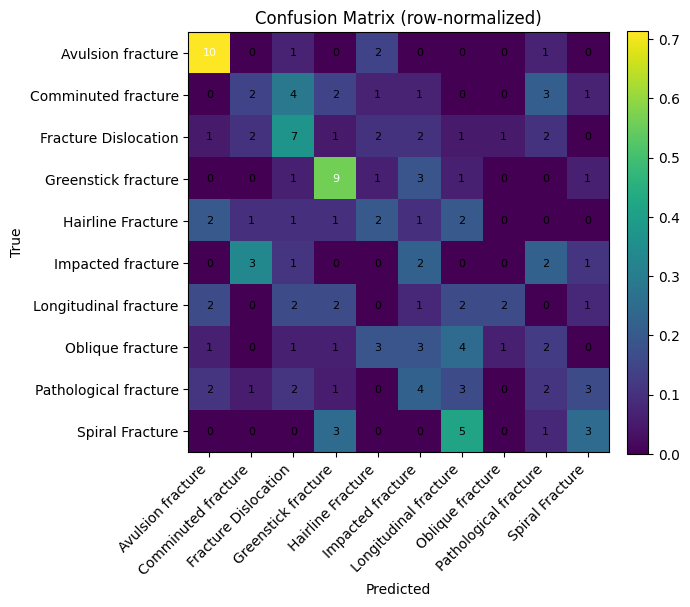

In [12]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import torch

# ---------- 1) Collect predictions & targets on test set ----------
model.eval()
all_targets = []
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        # If your test_loader ever returns (x, y, raw_img), handle that too:
        if len(batch) == 3:
            x, y, _ = batch
        else:
            x, y = batch

        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        all_targets.extend(y.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

all_targets = np.array(all_targets)
all_preds = np.array(all_preds)

classes_test = test_ds.classes   # class names, in correct order

print("Confusion matrix will use classes:", classes_test)

# ---------- 2) Plot confusion matrix (matplotlib-only) ----------
cm = confusion_matrix(all_targets, all_preds, labels=list(range(len(classes_test))))
cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)  # row-normalized

fig, ax = plt.subplots(
    figsize=(1.0 + 0.6 * len(classes_test), 1.0 + 0.6 * len(classes_test))
)
im = ax.imshow(cm_norm, interpolation="nearest")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_title("Confusion Matrix (row-normalized)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

ax.set_xticks(range(len(classes_test)))
ax.set_yticks(range(len(classes_test)))
ax.set_xticklabels(classes_test, rotation=45, ha="right")
ax.set_yticklabels(classes_test)

# annotate cells with raw counts
th = cm_norm.max() * 0.6
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        ax.text(
            j,
            i,
            str(val),
            ha="center",
            va="center",
            color="white" if cm_norm[i, j] > th else "black",
            fontsize=8,
        )

plt.tight_layout()
plt.show()

In [13]:
"""
This is just a sketch of how you might wire everything together.
You have to fill in your own:
  - model, target_layer
  - CLIP loading (clip_model, preprocess, tokenizer)
  - ref_loader that yields (tensor, label, raw_pil_image)
  - vocabulary list
"""

from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1) Load your CNN model (e.g., ResNet-50)
# model = models.resnet50(pretrained=True)
target_layer = model.layer4  # Choosing which layer to observe GradCAM, typical for CAM on ResNet

# 2) Load CLIP (example using open_clip, but you can use any CLIP implementation)
import open_clip
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)
clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")
feature_dim_clip = clip_model.text_projection.shape[1]

# 3) Prepare a reference loader (YOU must define a dataset that returns raw PIL images)

# 5) Build vocabulary
# vocab_phrases = classes

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


In [20]:
import json
import requests

# 1) Google Drive file info
file_id = "1RjpU6L0-6BeYTWPR1gUnVb2T0yb8LAxl"
download_url = f"https://drive.google.com/uc?export=download&id={file_id}"

# 2) Download the file
out_path = "fracture_xray_descriptors.json"

response = requests.get(download_url)
response.raise_for_status()  # will raise an error if download failed

with open(out_path, "wb") as f:
    f.write(response.content)

print(f"Downloaded to {out_path}")

# 3) Load the JSON and get the descriptors list
with open(out_path, "r") as f:
    data = json.load(f)

vocab_phrases = data["descriptors"]
print(f"Loaded {len(vocab_phrases)} descriptors")
print(vocab_phrases[:10])  # peek at the first few

Downloaded to fracture_xray_descriptors.json
Loaded 224 descriptors
['bone', 'long bone', 'shaft', 'diaphysis', 'metaphysis', 'epiphysis', 'growth plate', 'physis', 'cortex', 'cortical bone']


In [21]:
# 4) Estimate channel semantics
estimator = ChannelSemanticEstimator(
    model=model,
    target_layer=target_layer,
    clip_model=clip_model,
    clip_preprocess=clip_preprocess,
    device=device,
    feature_dim_clip=feature_dim_clip,
)
estimator.fit(all_train_loader, M=100, max_batches=100)  # you can cap for speed
channel_semantics = estimator.channel_semantics  # [C, D_clip]

In [22]:
print("Channel semantics shape:", channel_semantics.shape)

Channel semantics shape: torch.Size([2048, 512])


In [23]:
# 6) Create TextCAM explainer
textcam = TextCAM(
    model=model,
    target_layer=target_layer,
    clip_model=clip_model,
    clip_tokenizer=clip_tokenizer,
    clip_preprocess=clip_preprocess,
    vocab_phrases=vocab_phrases,
    device=device,
    channel_semantics=channel_semantics,
)

In [18]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def show_gradcam_on_image(
    img_pil,
    model,
    gradcam,        # textcam.gradcam or your GradCAM instance
    transform,      # e.g. test_tf or val_tf
    device,
    class_idx=None, # if None, use model prediction
    title_prefix="",
    alpha=0.4,      # heatmap transparency
):
    """
    Draw Grad-CAM heatmap on top of img_pil.
    """
    model.eval()
    img_tensor = transform(img_pil).unsqueeze(0).to(device)  # [1,3,H,W]

    # Forward pass
    logits = model(img_tensor)
    if class_idx is None:
        class_idx = int(logits.argmax(dim=1).item())

    # Zero grads & backward on the chosen class
    model.zero_grad()
    score = logits[:, class_idx].sum()
    score.backward(retain_graph=True)

    # Get activations + gradients from GradCAM hooks
    A = gradcam.activations      # [1, C, h, w]
    G = gradcam.gradients        # [1, C, h, w]

    # Grad-CAM: weights = mean over spatial dims
    weights = G.mean(dim=(2, 3), keepdim=True)      # [1, C, 1, 1]
    cam = (weights * A).sum(dim=1, keepdim=True)    # [1, 1, h, w]
    cam = F.relu(cam)

    # Upsample to image size
    H, W = img_pil.size[1], img_pil.size[0]         # PIL: (W,H)
    cam = F.interpolate(cam, size=(H, W), mode="bilinear", align_corners=False)

    # Normalize to [0,1]
    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    # Convert original image to numpy [0,1]
    img_np = np.array(img_pil).astype(np.float32) / 255.0
    if img_np.ndim == 2:  # grayscale → RGB
        img_np = np.stack([img_np]*3, axis=-1)

    # Colorize heatmap (jet colormap)
    heatmap = plt.cm.jet(cam)[..., :3]  # drop alpha channel

    # Overlay: alpha * heatmap + (1-alpha) * image
    overlay = alpha * heatmap + (1 - alpha) * img_np
    overlay = np.clip(overlay, 0, 1)

    return overlay

    # Plot side-by-side: original + overlay
    # fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    # axes[0].imshow(img_np)
    # axes[0].set_title(f"{title_prefix}Original")
    # axes[0].axis("off")

    # axes[1].imshow(overlay)
    # axes[1].set_title(f"{title_prefix}Grad-CAM (class {class_idx})")
    # axes[1].axis("off")

    # plt.tight_layout()
    # plt.show()


Classes in test_ds: ['Avulsion fracture', 'Comminuted fracture', 'Fracture Dislocation', 'Greenstick fracture', 'Hairline Fracture', 'Impacted fracture', 'Longitudinal fracture', 'Oblique fracture', 'Pathological fracture', 'Spiral Fracture']
Chosen indices per class: {0: 0, 1: 14, 2: 28, 3: 47, 4: 63, 5: 73, 6: 82, 7: 94, 8: 110, 9: 128}


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


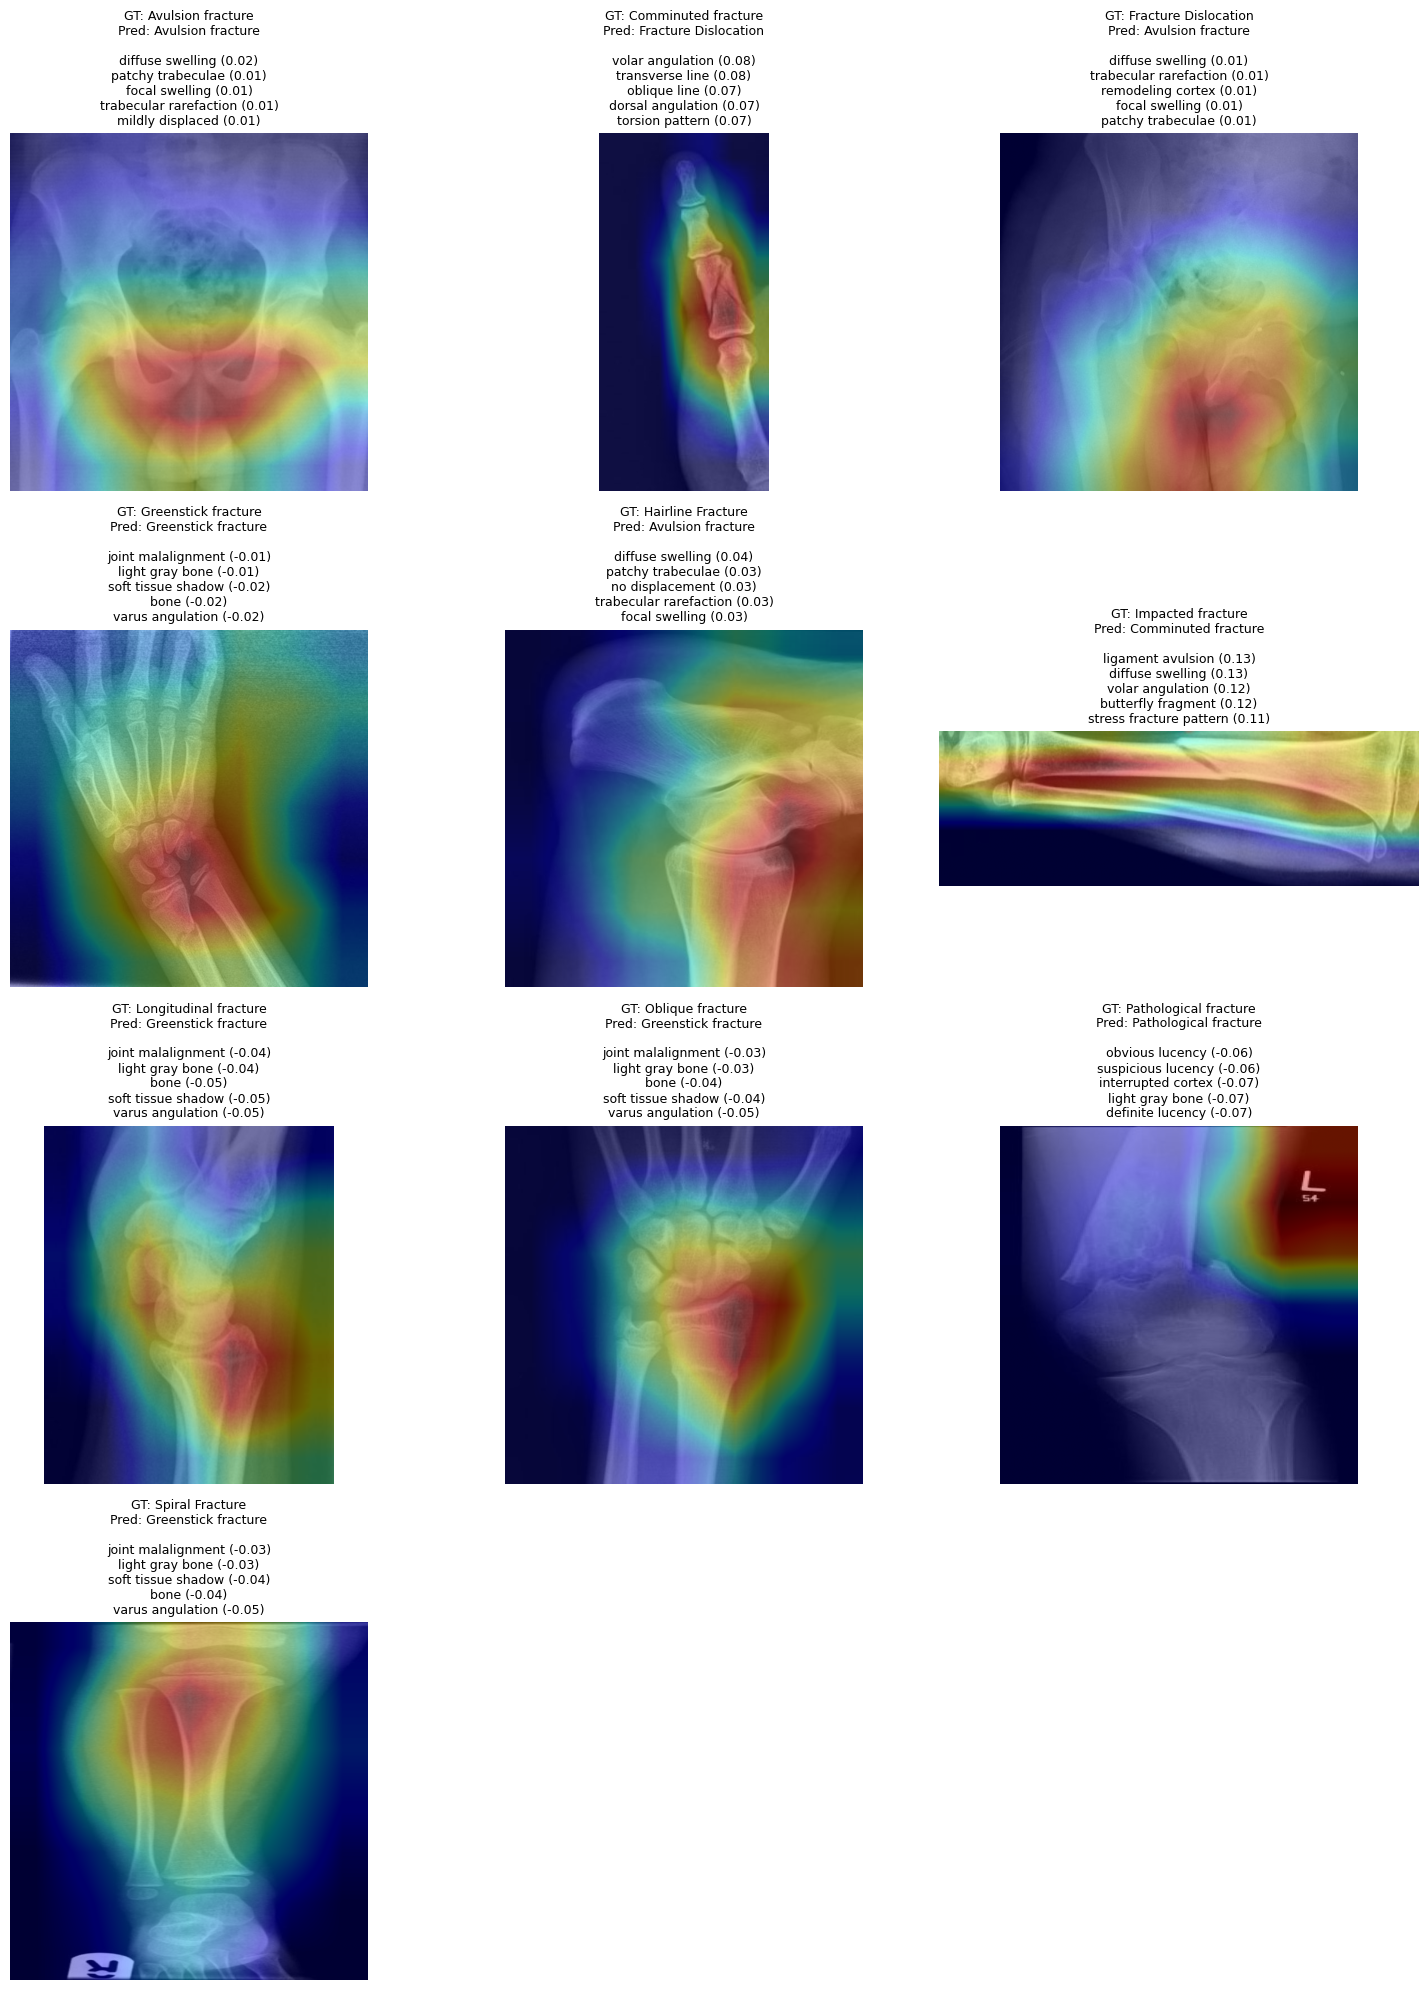

In [24]:
import math
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1) Pick one sample index per class from test_ds
idx_per_class = {}  # class_idx -> dataset index

for ds_idx, (path, class_idx) in enumerate(test_ds.samples):
    if class_idx not in idx_per_class:
        idx_per_class[class_idx] = ds_idx  # first sample for that class

print("Classes in test_ds:", test_ds.classes)
print("Chosen indices per class:", idx_per_class)

# 2) Set up a 3-column grid
num_classes = len(idx_per_class)
n_cols = 3
n_rows = math.ceil(num_classes / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))

# Ensure axes is always 2D array
axes = np.array(axes).reshape(n_rows, n_cols)

# 3) Loop over classes and fill the grid
for i, (class_idx, ds_idx) in enumerate(sorted(idx_per_class.items())):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]

    img_path, _ = test_ds.samples[ds_idx]
    img_pil = Image.open(img_path).convert("RGB")
    img_pil_gradcam = show_gradcam_on_image(
        img_pil=img_pil,
        model=textcam.model,
        gradcam=textcam.gradcam,  # the GradCAM we built inside TextCAM
        transform=test_tf,
        device=device,
        class_idx=None,           # None → use predicted class
        title_prefix="Spiral Fracture – ",  # optional
        alpha=0.4,
    )

    # Preprocess for the classifier (same as test_tf)
    x_model = test_tf(img_pil).unsqueeze(0).to(device)

    # Model prediction
    with torch.no_grad():
        logits = model(x_model)
        pred_idx = int(logits.argmax(dim=1).item())

    true_class_name = test_ds.classes[class_idx]
    pred_class_name = test_ds.classes[pred_idx]

    # TextCAM explanations (top-5 phrases)
    explanations = textcam.explain(x_model, pred_idx, top_k=5)

    # --- Plot ---
    ax.imshow(img_pil_gradcam, cmap=None)
    ax.axis("off")

    # Compact title text
    phrases_str = "\n".join(
        [f"{phrase} ({score:.2f})" for phrase, score in explanations]
    )

    ax.set_title(
        f"GT: {true_class_name}\nPred: {pred_class_name}\n\n{phrases_str}",
        fontsize=9,
    )

# 4) Hide any unused axes (if num_classes isn't a multiple of 3)
for j in range(num_classes, n_rows * n_cols):
    row = j // n_cols
    col = j % n_cols
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## Perturbation Test

In [34]:
import torch
import torch.nn.functional as F

def compute_cam_for_input(gradcam, x, class_idx):
    """
    gradcam: textcam.gradcam
    x:       (1, 3, H, W) tensor on device
    class_idx: int

    Returns: cam (H, W) in [0, 1], *same H,W as x*
    """
    # 1) Compute channel weights for this image + class
    w_c = gradcam.get_cam_weights(x, class_idx)     # [C]

    # 2) Activations from target layer: [1, C, Hc, Wc]
    activations = gradcam.get_activations()

    # 3) Weighted sum → small CAM [1, Hc, Wc]
    cam_small = (w_c.view(1, -1, 1, 1) * activations).sum(dim=1, keepdim=True)  # [1, 1, Hc, Wc]
    cam_small = F.relu(cam_small)

    # 4) Upsample CAM to input resolution
    H, W = x.shape[-2:]
    cam = F.interpolate(cam_small, size=(H, W), mode="bilinear", align_corners=False)  # [1, 1, H, W]
    cam = cam.squeeze(0).squeeze(0)  # [H, W]

    # 5) Normalize to [0, 1]
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    return cam

In [35]:
def make_topk_mask(cam, drop_ratio=0.15):
    H, W = cam.shape
    num_pixels = H * W
    k = max(1, int(drop_ratio * num_pixels))

    flat = cam.view(-1)
    _, idx = torch.topk(flat, k, largest=True)

    mask_flat = torch.zeros_like(flat, dtype=torch.bool)
    mask_flat[idx] = True
    return mask_flat.view(H, W)


def make_random_mask_like(cam, drop_ratio=0.15):
    H, W = cam.shape
    num_pixels = H * W
    k = max(1, int(drop_ratio * num_pixels))

    mask_flat = torch.zeros(num_pixels, dtype=torch.bool, device=cam.device)
    perm = torch.randperm(num_pixels, device=cam.device)
    mask_flat[perm[:k]] = True
    return mask_flat.view(H, W)


def apply_mask_to_input(x, mask):
    # mask: (H, W) → (1, 1, H, W)
    mask_4d = mask.view(1, 1, *mask.shape).to(x.device)
    # True = zero out
    return x * (~mask_4d)

In [36]:
import numpy as np

@torch.no_grad()
def get_class_logit(model, x, class_idx: int) -> float:
    """
    model: your ResNet50 classifier
    x: (1, 3, H, W)
    class_idx: int (fracture class index)
    """
    logits = model(x)           # [1, num_classes]
    if isinstance(logits, (tuple, list)):
        logits = logits[0]
    return float(logits[0, class_idx].item())

def perturbation_test(
    model,
    gradcam,
    data_loader,
    device,
    drop_ratio=0.15,
    max_images=None,   # e.g. 200 for a quick run
):
    """
    For each image:
      - compute CAM for the ground-truth class
      - mask top drop_ratio of pixels (high CAM)
      - mask same number of random pixels
      - measure the logit drop

    Returns: summary dict with means / stds.
    """
    model.eval()
    model.to(device)

    drops_top = []
    drops_rand = []

    n_seen = 0

    for images, labels in data_loader:
        images = images.to(device)
        labels = labels.to(device)

        batch_size = images.size(0)
        for i in range(batch_size):
            if max_images is not None and n_seen >= max_images:
                break

            x = images[i:i+1]               # (1, C, H, W)
            cls = int(labels[i].item())     # ground-truth fracture class

            # 1) Original logit for the ground-truth class
            orig_logit = get_class_logit(model, x, cls)

            # 2) Compute CAM (needs gradients)
            cam = compute_cam_for_input(gradcam, x.clone(), cls)  # (H, W)

            # 3) Build masks
            top_mask  = make_topk_mask(cam, drop_ratio=drop_ratio)
            rand_mask = make_random_mask_like(cam, drop_ratio=drop_ratio)

            # 4) Apply masks
            x_top  = apply_mask_to_input(x, top_mask)   # mask high-CAM region
            x_rand = apply_mask_to_input(x, rand_mask)  # mask random region

            # 5) Logits after masking (no grad needed)
            top_logit  = get_class_logit(model, x_top, cls)
            rand_logit = get_class_logit(model, x_rand, cls)

            drops_top.append(orig_logit - top_logit)
            drops_rand.append(orig_logit - rand_logit)

            n_seen += 1

        if max_images is not None and n_seen >= max_images:
            break

    drops_top  = np.array(drops_top)
    drops_rand = np.array(drops_rand)

    summary = {
        "drop_ratio": drop_ratio,
        "n_samples": int(n_seen),
        "top_mean": float(drops_top.mean()),
        "top_std":  float(drops_top.std()),
        "rand_mean": float(drops_rand.mean()),
        "rand_std":  float(drops_rand.std()),
    }
    return summary

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

summary = perturbation_test(
    model=textcam.model,
    gradcam=textcam.gradcam,
    data_loader=test_loader,
    device=device,
    drop_ratio=0.15,    # top 15% CAM pixels
    max_images=200,     # or None to use full test set
)

print(summary)

{'drop_ratio': 0.15, 'n_samples': 140, 'top_mean': 1.211827556476263, 'top_std': 1.3212281709010703, 'rand_mean': 1.1528381757305137, 'rand_std': 2.200211224760599}


The key question: is CAM clearly better than random?

For a strongly faithful CAM, you’d hope to see:

top_mean >> rand_mean
(e.g., top_mean = 1.5, rand_mean = 0.3 or similar)

In your case:

top_mean ~ 1.21

rand_mean ~ 1.15

Those are very close — almost the same average drop.

So the current result says:

“When I remove the most CAM-important pixels, the model’s score drops by about 1.21.
When I remove a random set of pixels of the same size, it drops by about 1.15.
There is no strong evidence that the CAM region is more important than a random region (on average).”